In [4]:
import kagglehub
khanfashee_nih_chest_x_ray_14_224x224_resized_path = kagglehub.dataset_download('khanfashee/nih-chest-x-ray-14-224x224-resized')

print('Data source import complete.')

Data source import complete.


In [5]:
import os
import random
import warnings

import cv2
import numpy as np
import pandas as pd
from PIL import Image
import albumentations as A
from tqdm.notebook import tqdm
import seaborn as sns
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import LinearLR, SequentialLR, CosineAnnealingLR, ReduceLROnPlateau

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


import timm
from timm.data import create_transform

from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

In [6]:
def set_seed(seed=42):
    """
    Sets all seeds for reproducibility.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # For multi-GPU setups

    # Critical for CuDNN reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"Seeds set to {seed} for reproducibility.")

set_seed(42)

# Plot defaults
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],  # Sets the specific font
    'font.size': 17, 
    'axes.labelsize': 17, 
    'axes.titlesize': 20, 
    'legend.fontsize': 17, 
    'xtick.labelsize': 17, 
    'ytick.labelsize': 17
})

Seeds set to 42 for reproducibility.


In [7]:
# Define dataset paths for the Kaggle environment
DATA_DIR = khanfashee_nih_chest_x_ray_14_224x224_resized_path
CSV_PATH = os.path.join(DATA_DIR, 'Data_Entry_2017.csv')
IMAGE_DIR = os.path.join(DATA_DIR, 'images-224/images-224/')
MODEL_DIR = '../weights/RANDOMSAMPLING.pth'
BBOX_DIR = os.path.join(DATA_DIR, 'BBox_List_2017_Official_NIH.csv')


# 14 Pathology classes evaluated in ChestX-ray14
DISEASES = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule',
    'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]

In [8]:
df = pd.read_csv(CSV_PATH)

# Add full image path for the PyTorch dataloader later
df['Image_Path'] = df['Image Index'].apply(lambda x: os.path.join(IMAGE_DIR, x))

print(f"Total records loaded: {len(df)}")

# Split the pipe-separated strings into lists, handling 'No Finding' as an empty list
df['Labels'] = df['Finding Labels'].apply(lambda x: x.split('|') if x != 'No Finding' else [])

# Initialize and fit the binarizer for the 14 specific diseases
mlb = MultiLabelBinarizer(classes=DISEASES)
encoded_labels = mlb.fit_transform(df['Labels'])

# Append encoded labels as new columns to the dataframe
for i, disease in enumerate(DISEASES):
    df[disease] = encoded_labels[:, i]


# Initialize GroupShuffleSplit for the first split (Hold out 20% for Testing)
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# 1. Split into (Train+Val) and Test
train_val_idx, test_idx = next(gss_test.split(df, groups=df['Patient ID']))
train_val_df = df.iloc[train_val_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

# Initialize a second GroupShuffleSplit for the Train/Val split
# Following the paper: 80% of the remaining data forms the training split
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# 2. Split (Train+Val) into Train and Validation
train_idx, val_idx = next(gss_val.split(train_val_df, groups=train_val_df['Patient ID']))
train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

print(f"Total distinct patients: {df['Patient ID'].nunique()}")
print(f"Training images: {len(train_df)} ({(len(train_df)/len(df))*100:.1f}%)")
print(f"Validation images: {len(val_df)} ({(len(val_df)/len(df))*100:.1f}%)")
print(f"Testing images: {len(test_df)} ({(len(test_df)/len(df))*100:.1f}%)")

# Verify absolutely no patient overlap across any of the three sets
train_patients = set(train_df['Patient ID'])
val_patients = set(val_df['Patient ID'])
test_patients = set(test_df['Patient ID'])

assert len(train_patients.intersection(val_patients)) == 0, "Leakage: Train/Val overlap"
assert len(train_patients.intersection(test_patients)) == 0, "Leakage: Train/Test overlap"
assert len(val_patients.intersection(test_patients)) == 0, "Leakage: Val/Test overlap"

print("Verification passed: No patient overlap across Train, Validation, and Test sets.")

Total records loaded: 112120
Total distinct patients: 30805
Training images: 72061 (64.3%)
Validation images: 17765 (15.8%)
Testing images: 22294 (19.9%)
Verification passed: No patient overlap across Train, Validation, and Test sets.


In [9]:
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        """
        Args:
            dataframe (pd.DataFrame): The train or validation dataframe.
            transform (callable, optional): Transform pipeline (augmentation + resize + normalize).
                                            Pass train_transform for training, base_transform for val/test.
        """
        self.dataframe = dataframe
        self.transform = transform
        self.image_paths = dataframe['Image_Path'].values
        self.labels = dataframe[DISEASES].values

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image = np.array(Image.open(self.image_paths[idx]).convert('RGB'))

        if self.transform:
            image = self.transform(image=image)["image"]

        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return image, label
    
    
IMG_SIZE = 224
DATASET_MEAN = np.array([0.4982, 0.4982, 0.4982])
DATASET_STD = np.array([0.2484, 0.2484, 0.2484])

print("Building train, validation, and test transforms...")

# 1. Base transform (always applied): Resize + Normalize
base_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE, interpolation=cv2.INTER_CUBIC),
    A.Normalize(mean=DATASET_MEAN, std=DATASET_STD),
    ToTensorV2(),
])


# Define batch size
BATCH_SIZE = 64  # Warning: Consider lowering to 32/64 if CUDA Out of Memory occurs


# Validation dataset (no augmentation, just base transforms)
val_dataset = ChestXrayDataset(
    dataframe=val_df,
    transform=base_transform,                     # No augmentations
)
test_dataset = ChestXrayDataset(
    dataframe=test_df,
    transform=base_transform,                     # No augmentations
)

Building train, validation, and test transforms...


In [10]:
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,      # No need to shuffle test data
    num_workers=0,
    pin_memory=True
)

print(f"DataLoaders created. Batch size: {BATCH_SIZE}")
print(f"Validation batches: {len(val_loader)}")
print(f"Testing batches: {len(test_loader)}")

# Quick sanity check
sample_images, sample_labels = next(iter(test_loader))
print(f"Sample image batch shape: {sample_images.shape}")
print(f"Sample label batch shape: {sample_labels.shape}")

DataLoaders created. Batch size: 64
Validation batches: 278
Testing batches: 349
Sample image batch shape: torch.Size([64, 3, 224, 224])
Sample label batch shape: torch.Size([64, 14])


In [11]:
print(timm.list_models("*resnet50*"))

['cspresnet50', 'cspresnet50d', 'cspresnet50w', 'ecaresnet50d', 'ecaresnet50d_pruned', 'ecaresnet50t', 'gcresnet50t', 'lambda_resnet50ts', 'legacy_seresnet50', 'nf_ecaresnet50', 'nf_resnet50', 'nf_seresnet50', 'resnet50', 'resnet50_clip', 'resnet50_clip_gap', 'resnet50_gn', 'resnet50_mlp', 'resnet50c', 'resnet50d', 'resnet50s', 'resnet50t', 'resnet50x4_clip', 'resnet50x4_clip_gap', 'resnet50x16_clip', 'resnet50x16_clip_gap', 'resnet50x64_clip', 'resnet50x64_clip_gap', 'seresnet50', 'seresnet50t', 'skresnet50', 'skresnet50d', 'vit_base_resnet50d_224', 'vit_small_resnet50d_s16_224', 'wide_resnet50_2']


In [12]:
class DenseCheX(nn.Module):
    def __init__(self, num_classes=14, model_name='densetnet121'):
        super().__init__()
        # By passing num_classes=14, timm automatically drops the 1000-class
        # ImageNet head and replaces it with a single nn.Linear(1024, 14) layer.
        self.model = timm.create_model(
            model_name,
            # 'swin.a1_in1k'
            # efficientnetv2_rw_s.ra2_in1k
            pretrained=True,
            num_classes=num_classes
        )

    def forward(self, x):
        # Outputs raw logits for the 14 classes to be used with BCEWithLogitsLoss
        return self.model(x)
    
# Check hardware availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [13]:
# Load all three models
densenet = DenseCheX(num_classes=14, model_name='densenet121').to(device)
swin = DenseCheX(num_classes=14, model_name='swin_small_patch4_window7_224.ms_in22k').to(device)
efficientnet = DenseCheX(num_classes=14, model_name='efficientnetv2_rw_s.ra2_in1k').to(device)
resnet = DenseCheX(num_classes=14, model_name="resnet50").to(device)

densenet.load_state_dict(torch.load('../weights/RANDOMSAMPLING.pth'))
swin.load_state_dict(torch.load('../weights/SWIN.pth'))
efficientnet.load_state_dict(torch.load('../weights/EFFICIENTNET.pth'))
resnet.load_state_dict(torch.load('../weights/RESNET50.pth'))

for m in [densenet, swin, efficientnet, resnet]:
    m.eval()

In [14]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Ensemble Inference"):
        images = images.to(device)

        probs_bce    = torch.sigmoid(densenet(images))
        probs_focal  = torch.sigmoid(swin(images))
        probs_wfocal = torch.sigmoid(efficientnet(images))
        probs_resnet = torch.sigmoid(resnet(images))

        stacked = torch.stack([probs_bce, probs_focal, probs_wfocal, probs_resnet], dim=0)
        ensemble_probs = stacked.mean(dim=0)

        all_preds.append(ensemble_probs.cpu().numpy())
        all_labels.append(labels.numpy())

ensemble_preds_np = np.vstack(all_preds)
ensemble_labels_np = np.vstack(all_labels)

Ensemble Inference:   0%|          | 0/349 [00:00<?, ?it/s]

In [15]:
import numpy as np
import pandas as pd
from itertools import combinations
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm


def delong_test(y_true, prob_a, prob_b):
    y_true = np.asarray(y_true)
    prob_a = np.asarray(prob_a)
    prob_b = np.asarray(prob_b)

    def auc_components(y, p):
        pos = p[y == 1]
        neg = p[y == 0]

        # Guard against degenerate cases where variance estimates are undefined.
        if len(pos) < 2 or len(neg) < 2:
            return np.nan, np.nan

        v10 = np.array([np.mean(pi > neg) + 0.5 * np.mean(pi == neg) for pi in pos])
        v01 = np.array([np.mean(pos > nj) + 0.5 * np.mean(pos == nj) for nj in neg])

        auc = v10.mean()
        var = np.var(v10, ddof=1) / len(pos) + np.var(v01, ddof=1) / len(neg)
        return auc, var

    auc_a, var_a = auc_components(y_true, prob_a)
    auc_b, var_b = auc_components(y_true, prob_b)

    if np.isnan(auc_a) or np.isnan(auc_b) or np.isnan(var_a) or np.isnan(var_b):
        return np.nan, np.nan

    se = np.sqrt(var_a + var_b)
    z = (auc_a - auc_b) / se if se > 0 else 0.0
    p = 2 * (1 - norm.cdf(abs(z)))
    return auc_a - auc_b, p


def compare_all_pairs(preds_dict, labels, diseases, anchor_model=None):
    model_names = list(preds_dict.keys())
    pairs = list(combinations(model_names, 2))

    if anchor_model is not None:
        pairs = [(m1, m2) for (m1, m2) in pairs if anchor_model in (m1, m2)]

    records = []

    for disease_idx, disease in enumerate(diseases):
        y_true = labels[:, disease_idx]

        for (m1, m2) in pairs:
            diff, p = delong_test(
                y_true,
                preds_dict[m1][:, disease_idx],
                preds_dict[m2][:, disease_idx],
            )

            records.append(
                {
                    "Pathology": disease,
                    "Model A": m1,
                    "Model B": m2,
                    "Pair": f"{m1} vs {m2}",
                    "AUC diff": diff,
                    "p_raw": p,
                }
            )

    df = pd.DataFrame(records)

    # Benjamini-Hochberg correction across all generated tests.
    p_corrected = np.full(len(df), np.nan)
    valid_mask = df["p_raw"].notna()

    if valid_mask.any():
        _, p_corr_valid, _, _ = multipletests(df.loc[valid_mask, "p_raw"], method="fdr_bh")
        p_corrected[valid_mask.values] = p_corr_valid

    df["p_corrected"] = p_corrected
    df["significant"] = df["p_corrected"] < 0.05

    return df


# Reuse previously computed per-model prediction arrays when available.
if "preds_np" in globals() and "labels_np" in globals():
    densenet_preds = preds_np["DenseNet"]
    efficientnet_preds = preds_np["EfficientNet"]
    swin_preds = preds_np["Swin"]
    resnet_preds = preds_np["ResNet50"]
    labels = labels_np
else:
    densenet_buf, efficientnet_buf, swin_buf, resnet_buf, label_buf = [], [], [], [], []

    with torch.no_grad():
        for images, batch_labels in tqdm(test_loader, desc="Model-wise Inference for DeLong"):
            images = images.to(device)

            densenet_buf.append(torch.sigmoid(densenet(images)).cpu().numpy())
            efficientnet_buf.append(torch.sigmoid(efficientnet(images)).cpu().numpy())
            swin_buf.append(torch.sigmoid(swin(images)).cpu().numpy())
            resnet_buf.append(torch.sigmoid(resnet(images)).cpu().numpy())
            label_buf.append(batch_labels.numpy())

    densenet_preds = np.vstack(densenet_buf)
    efficientnet_preds = np.vstack(efficientnet_buf)
    swin_preds = np.vstack(swin_buf)
    resnet_preds = np.vstack(resnet_buf)
    labels = np.vstack(label_buf)

ensemble_preds = (densenet_preds + efficientnet_preds + swin_preds + resnet_preds) / 4.0

preds_dict = {
    "DenseNet": densenet_preds,
    "EfficientNet": efficientnet_preds,
    "Swin": swin_preds,
    "ResNet50": resnet_preds,
    "Ensemble": ensemble_preds,
}

# Requested output: comparisons where Ensemble is involved.
delong_results = compare_all_pairs(preds_dict, labels, DISEASES, anchor_model="Ensemble")

# Keep downstream compatibility with existing notebook cells.
delong_bh_results = delong_results.copy()
delong_bh_results["p_bh"] = delong_bh_results["p_corrected"]

print("Ensemble vs other models: significant labels per pair (BH p<0.05)")
print(delong_bh_results.groupby("Pair")["significant"].sum().sort_values(ascending=False))

print("\nFull ensemble comparison table:")
display(
    delong_bh_results.sort_values(["Pair", "p_corrected", "Pathology"])
)


Model-wise Inference for DeLong: 100%|██████████| 349/349 [06:44<00:00,  1.16s/it]


Ensemble vs other models: significant labels per pair (BH p<0.05)
Pair
ResNet50 vs Ensemble        1
Swin vs Ensemble            1
DenseNet vs Ensemble        0
EfficientNet vs Ensemble    0
Name: significant, dtype: int64

Full ensemble comparison table:


,Pathology,Model A,Model B,Pair,AUC diff,p_raw,p_corrected,significant,p_bh
20,Emphysema,DenseNet,Ensemble,DenseNet vs Ensemble,-0.025433,0.007643,0.073287,False,0.073287
40,Nodule,DenseNet,Ensemble,DenseNet vs Ensemble,-0.026275,0.010470,0.073287,False,0.073287
52,Pneumothorax,DenseNet,Ensemble,DenseNet vs Ensemble,-0.017765,0.024467,0.105397,False,0.105397
32,Infiltration,DenseNet,Ensemble,DenseNet vs Ensemble,-0.013305,0.032246,0.110511,False,0.110511
0,Atelectasis,DenseNet,Ensemble,DenseNet vs Ensemble,-0.013300,0.037019,0.115171,False,0.115171
16,Effusion,DenseNet,Ensemble,DenseNet vs Ensemble,-0.008899,0.061203,0.171367,False,0.171367
36,Mass,DenseNet,Ensemble,DenseNet vs Ensemble,-0.014283,0.100627,0.225404,False,0.225404
8,Consolidation,DenseNet,Ensemble,DenseNet vs Ensemble,-0.014205,0.122450,0.263739,False,0.263739
24,Fibrosis,DenseNet,Ensemble,DenseNet vs Ensemble,-0.021381,0.184453,0.303804,False,0.303804
48,Pneumonia,DenseNet,Ensemble,DenseNet vs Ensemble,-0.023595,0.219865,0.307811,False,0.307811


In [16]:
ensemble_only = delong_bh_results[delong_bh_results["Pair"].str.contains("Ensemble")].copy()

summary = (
    ensemble_only.groupby("Pair", as_index=False)
    .agg(
        total_tests=("Pathology", "count"),
        significant_count=("significant", "sum"),
        min_p_bh=("p_bh", "min"),
    )
    .sort_values("significant_count", ascending=False)
)

print("Ensemble pairwise summary (BH corrected):")
display(summary)

print("\nSignificant pathology-level results for ensemble comparisons (p_bh < 0.05):")
ensemble_sig = (
    ensemble_only[ensemble_only["significant"]]
    .sort_values(["Pair", "p_bh"])
    [["Pathology", "Model A", "Model B", "AUC diff", "p_raw", "p_bh"]]
)
display(ensemble_sig)

Ensemble pairwise summary (BH corrected):


,Pair,total_tests,significant_count,min_p_bh
2,ResNet50 vs Ensemble,14,1,0.048940
3,Swin vs Ensemble,14,1,0.048940
0,DenseNet vs Ensemble,14,0,0.073287
1,EfficientNet vs Ensemble,14,0,0.068000



Significant pathology-level results for ensemble comparisons (p_bh < 0.05):


,Pathology,Model A,Model B,AUC diff,p_raw,p_bh
43,Nodule,ResNet50,Ensemble,-0.033888,0.001143,0.04894
42,Nodule,Swin,Ensemble,-0.032359,0.001748,0.04894


In [17]:
all_pathologies = sorted(ensemble_only["Pathology"].unique().tolist())

for pair in sorted(ensemble_only["Pair"].unique()):
    sub = ensemble_only[ensemble_only["Pair"] == pair].copy()
    sig = sub[sub["significant"]].sort_values("p_bh")
    sig_list = sig["Pathology"].tolist()
    nonsig_list = [p for p in all_pathologies if p not in sig_list]

    print(f"{pair}: {len(sig_list)}/{len(all_pathologies)} significant (BH p<0.05)")
    print("  Significant:", ", ".join(sig_list) if sig_list else "None")
    print("  Non-significant:", ", ".join(nonsig_list) if nonsig_list else "None")
    print()


DenseNet vs Ensemble: 0/14 significant (BH p<0.05)
  Significant: None
  Non-significant: Atelectasis, Cardiomegaly, Consolidation, Edema, Effusion, Emphysema, Fibrosis, Hernia, Infiltration, Mass, Nodule, Pleural_Thickening, Pneumonia, Pneumothorax

EfficientNet vs Ensemble: 0/14 significant (BH p<0.05)
  Significant: None
  Non-significant: Atelectasis, Cardiomegaly, Consolidation, Edema, Effusion, Emphysema, Fibrosis, Hernia, Infiltration, Mass, Nodule, Pleural_Thickening, Pneumonia, Pneumothorax

ResNet50 vs Ensemble: 1/14 significant (BH p<0.05)
  Significant: Nodule
  Non-significant: Atelectasis, Cardiomegaly, Consolidation, Edema, Effusion, Emphysema, Fibrosis, Hernia, Infiltration, Mass, Pleural_Thickening, Pneumonia, Pneumothorax

Swin vs Ensemble: 1/14 significant (BH p<0.05)
  Significant: Nodule
  Non-significant: Atelectasis, Cardiomegaly, Consolidation, Edema, Effusion, Emphysema, Fibrosis, Hernia, Infiltration, Mass, Pleural_Thickening, Pneumonia, Pneumothorax



In [18]:
from statsmodels.stats.multitest import multipletests

ensemble_only_56 = delong_bh_results[delong_bh_results["Pair"].str.contains("Ensemble")].copy()
rej56, pbh56, _, _ = multipletests(ensemble_only_56["p_raw"].values, alpha=0.05, method="fdr_bh")
ensemble_only_56["p_bh_ensemble_only"] = pbh56
ensemble_only_56["significant_ensemble_only"] = rej56

print("BH over ensemble-only tests (56 total):")
print(ensemble_only_56.groupby("Pair")["significant_ensemble_only"].sum().sort_values(ascending=False))

print("\nPathologies not significant (if any):")
for pair in sorted(ensemble_only_56["Pair"].unique()):
    sub = ensemble_only_56[ensemble_only_56["Pair"] == pair]
    nonsig = sub.loc[~sub["significant_ensemble_only"], "Pathology"].tolist()
    print(f"{pair}: {', '.join(nonsig) if nonsig else 'None'}")


BH over ensemble-only tests (56 total):
Pair
ResNet50 vs Ensemble        1
Swin vs Ensemble            1
DenseNet vs Ensemble        0
EfficientNet vs Ensemble    0
Name: significant_ensemble_only, dtype: int64

Pathologies not significant (if any):
DenseNet vs Ensemble: Atelectasis, Cardiomegaly, Consolidation, Edema, Effusion, Emphysema, Fibrosis, Hernia, Infiltration, Mass, Nodule, Pleural_Thickening, Pneumonia, Pneumothorax
EfficientNet vs Ensemble: Atelectasis, Cardiomegaly, Consolidation, Edema, Effusion, Emphysema, Fibrosis, Hernia, Infiltration, Mass, Nodule, Pleural_Thickening, Pneumonia, Pneumothorax
ResNet50 vs Ensemble: Atelectasis, Cardiomegaly, Consolidation, Edema, Effusion, Emphysema, Fibrosis, Hernia, Infiltration, Mass, Pleural_Thickening, Pneumonia, Pneumothorax
Swin vs Ensemble: Atelectasis, Cardiomegaly, Consolidation, Edema, Effusion, Emphysema, Fibrosis, Hernia, Infiltration, Mass, Pleural_Thickening, Pneumonia, Pneumothorax


In [19]:
# Full table of all BH-significant DeLong comparisons across all pairs and pathologies.
significant_comparisons = (
    delong_bh_results[delong_bh_results["significant"]]
    .sort_values(["Pair", "p_bh", "Pathology"], ascending=[True, True, True])
    .reset_index(drop=True)
)

print(f"Total significant comparisons (BH p<0.05): {len(significant_comparisons)}")

with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(significant_comparisons[["Pathology", "Model A", "Model B", "AUC diff", "p_raw", "p_bh"]])

os.makedirs("../artifacts/inference_analysis", exist_ok=True)
out_csv = "../artifacts/inference_analysis/delong_significant_comparisons.csv"
significant_comparisons.to_csv(out_csv, index=False)
print(f"Saved full significant-comparisons table to: {out_csv}")
significant_comparisons

Total significant comparisons (BH p<0.05): 2


,Pathology,Model A,Model B,AUC diff,p_raw,p_bh
0,Nodule,ResNet50,Ensemble,-0.033888,0.001143,0.04894
1,Nodule,Swin,Ensemble,-0.032359,0.001748,0.04894


Saved full significant-comparisons table to: ../artifacts/inference_analysis/delong_significant_comparisons.csv


,Pathology,Model A,Model B,Pair,AUC diff,p_raw,p_corrected,significant,p_bh
0,Nodule,ResNet50,Ensemble,ResNet50 vs Ensemble,-0.033888,0.001143,0.04894,True,0.04894
1,Nodule,Swin,Ensemble,Swin vs Ensemble,-0.032359,0.001748,0.04894,True,0.04894


In [20]:
from sklearn.metrics import (roc_auc_score, f1_score, confusion_matrix,
                             average_precision_score)

print("Calculating ensemble metrics with bootstrap CIs, AUPRC, calibration, and per-class threshold optimization...\n")


def _bootstrap_ci(true_labels, pred_probs, metric_fn, n_boot=1000, ci=0.95, seed=42):
    rng = np.random.default_rng(seed)
    n = len(true_labels)
    scores = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        bt, bp = true_labels[idx], pred_probs[idx]
        if len(np.unique(bt)) < 2:
            continue

        try:
            scores.append(metric_fn(bt, bp))
        except ValueError:
            continue

    if not scores:
        return (np.nan, np.nan)

    alpha = (1 - ci) / 2
    return (
        np.percentile(scores, 100 * alpha),
        np.percentile(scores, 100 * (1 - alpha))
    )


def _expected_calibration_error(true_labels, pred_probs, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n = len(true_labels)

    for i in range(n_bins):
        mask = (pred_probs >= bins[i]) & (pred_probs < bins[i + 1])
        if mask.sum() == 0:
            continue
        ece += (mask.sum() / n) * abs(true_labels[mask].mean() - pred_probs[mask].mean())

    return ece


def evaluate_metrics(preds, labels, diseases, n_boot=1000, raw=False):
    results = []

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        for i, disease in enumerate(diseases):
            true_labels = labels[:, i]
            pred_probs = preds[:, i]

            # --- AUROC + AUPRC ---
            try:
                auc = roc_auc_score(true_labels, pred_probs)
            except ValueError:
                auc = np.nan

            try:
                auprc = average_precision_score(true_labels, pred_probs)
            except ValueError:
                auprc = np.nan

            # --- Bootstrap CIs ---
            auroc_ci = _bootstrap_ci(true_labels, pred_probs, roc_auc_score, n_boot=n_boot)
            auprc_ci = _bootstrap_ci(true_labels, pred_probs, average_precision_score, n_boot=n_boot)

            # --- Calibration ---
            ece = _expected_calibration_error(true_labels, pred_probs)

            # --- Threshold optimization (binary F1) ---
            thresholds = np.linspace(0.01, 0.9, 181)
            best_f1, best_thresh = 0.0, 0.5
            best_metrics = {'Sens': 0.0, 'Spec': 0.0, 'Prec': 0.0}

            for thresh in thresholds:
                pred_binary = (pred_probs >= thresh).astype(int)
                f1 = f1_score(true_labels, pred_binary, average='macro', zero_division=0)

                if f1 > best_f1:
                    best_f1 = f1
                    best_thresh = thresh
                    tn, fp, fn, tp = confusion_matrix(true_labels, pred_binary, labels=[0, 1]).ravel()
                    best_metrics['Sens'] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
                    best_metrics['Spec'] = tn / (tn + fp) if (tn + fp) > 0 else 0.0
                    best_metrics['Prec'] = tp / (tp + fp) if (tp + fp) > 0 else 0.0

            results.append({
                'Pathology': disease,
                'Threshold': best_thresh,
                'AUROC': auc,
                'AUROC_CI': f'[{auroc_ci[0]:.3f}, {auroc_ci[1]:.3f}]' if not np.isnan(auc) else 'N/A',
                'AUPRC': auprc,
                'AUPRC_CI': f'[{auprc_ci[0]:.3f}, {auprc_ci[1]:.3f}]' if not np.isnan(auprc) else 'N/A',
                'ECE': ece,
                'F1': best_f1,
                'Sensitivity': best_metrics['Sens'],
                'Specificity': best_metrics['Spec'],
                'Precision': best_metrics['Prec'],
            })

    results_df = pd.DataFrame(results)

    mean_values = results_df.select_dtypes(include=[np.number]).mean()
    mean_row = pd.DataFrame([{'Pathology': 'MACRO AVG', **mean_values}])
    results_df = pd.concat([results_df, mean_row], ignore_index=True)

    if raw == True:
        return results_df

    fmt = {
        'Threshold': '{:.2f}', 'AUROC': '{:.3f}', 'AUPRC': '{:.3f}',
        'ECE': '{:.3f}', 'F1': '{:.3f}',
        'Sensitivity': '{:.3f}', 'Specificity': '{:.3f}', 'Precision': '{:.3f}'
    }
    for col, f in fmt.items():
        results_df[col] = results_df[col].map(lambda x: f.format(x) if pd.notna(x) else 'N/A')

    return results_df


results_df_raw = evaluate_metrics(
    preds=ensemble_preds_np,
    labels=ensemble_labels_np,
    diseases=DISEASES,
    n_boot=1000,
    raw=True
)

# Keep downstream compatibility with the confusion-matrix cell.
results = results_df_raw.iloc[:-1].to_dict(orient='records')

results_df = results_df_raw.copy()
fmt = {
    'Threshold': '{:.2f}', 'AUROC': '{:.3f}', 'AUPRC': '{:.3f}',
    'ECE': '{:.3f}', 'F1': '{:.3f}',
    'Sensitivity': '{:.3f}', 'Specificity': '{:.3f}', 'Precision': '{:.3f}'
}
for col, f in fmt.items():
    if col in results_df.columns:
        results_df[col] = results_df[col].map(lambda x: f.format(x) if pd.notna(x) else 'N/A')

display(results_df)

Calculating ensemble metrics with bootstrap CIs, AUPRC, calibration, and per-class threshold optimization...



,Pathology,Threshold,AUROC,AUROC_CI,AUPRC,AUPRC_CI,ECE,F1,Sensitivity,Specificity,Precision
0,Atelectasis,0.26,0.827,"[0.819, 0.836]",0.376,"[0.356, 0.397]",0.005,0.673,0.449,0.922,0.387
1,Cardiomegaly,0.20,0.929,"[0.920, 0.937]",0.336,"[0.299, 0.372]",0.004,0.703,0.479,0.978,0.381
2,Consolidation,0.13,0.828,"[0.815, 0.841]",0.180,"[0.161, 0.203]",0.005,0.612,0.395,0.933,0.207
3,Edema,0.17,0.899,"[0.884, 0.911]",0.178,"[0.153, 0.211]",0.003,0.624,0.350,0.974,0.217
4,Effusion,0.28,0.887,"[0.881, 0.893]",0.522,"[0.502, 0.543]",0.010,0.739,0.613,0.918,0.490
5,Emphysema,0.17,0.927,"[0.915, 0.938]",0.368,"[0.328, 0.413]",0.006,0.728,0.497,0.985,0.446
6,Fibrosis,0.12,0.823,"[0.801, 0.842]",0.114,"[0.091, 0.148]",0.003,0.585,0.176,0.988,0.191
7,Hernia,0.12,0.940,"[0.906, 0.970]",0.314,"[0.169, 0.466]",0.001,0.720,0.354,0.999,0.586
8,Infiltration,0.25,0.723,"[0.715, 0.731]",0.363,"[0.349, 0.378]",0.021,0.639,0.452,0.843,0.393
9,Mass,0.19,0.860,"[0.848, 0.871]",0.334,"[0.309, 0.364]",0.006,0.685,0.447,0.961,0.369


Generating confusion matrices for all 14 classes...


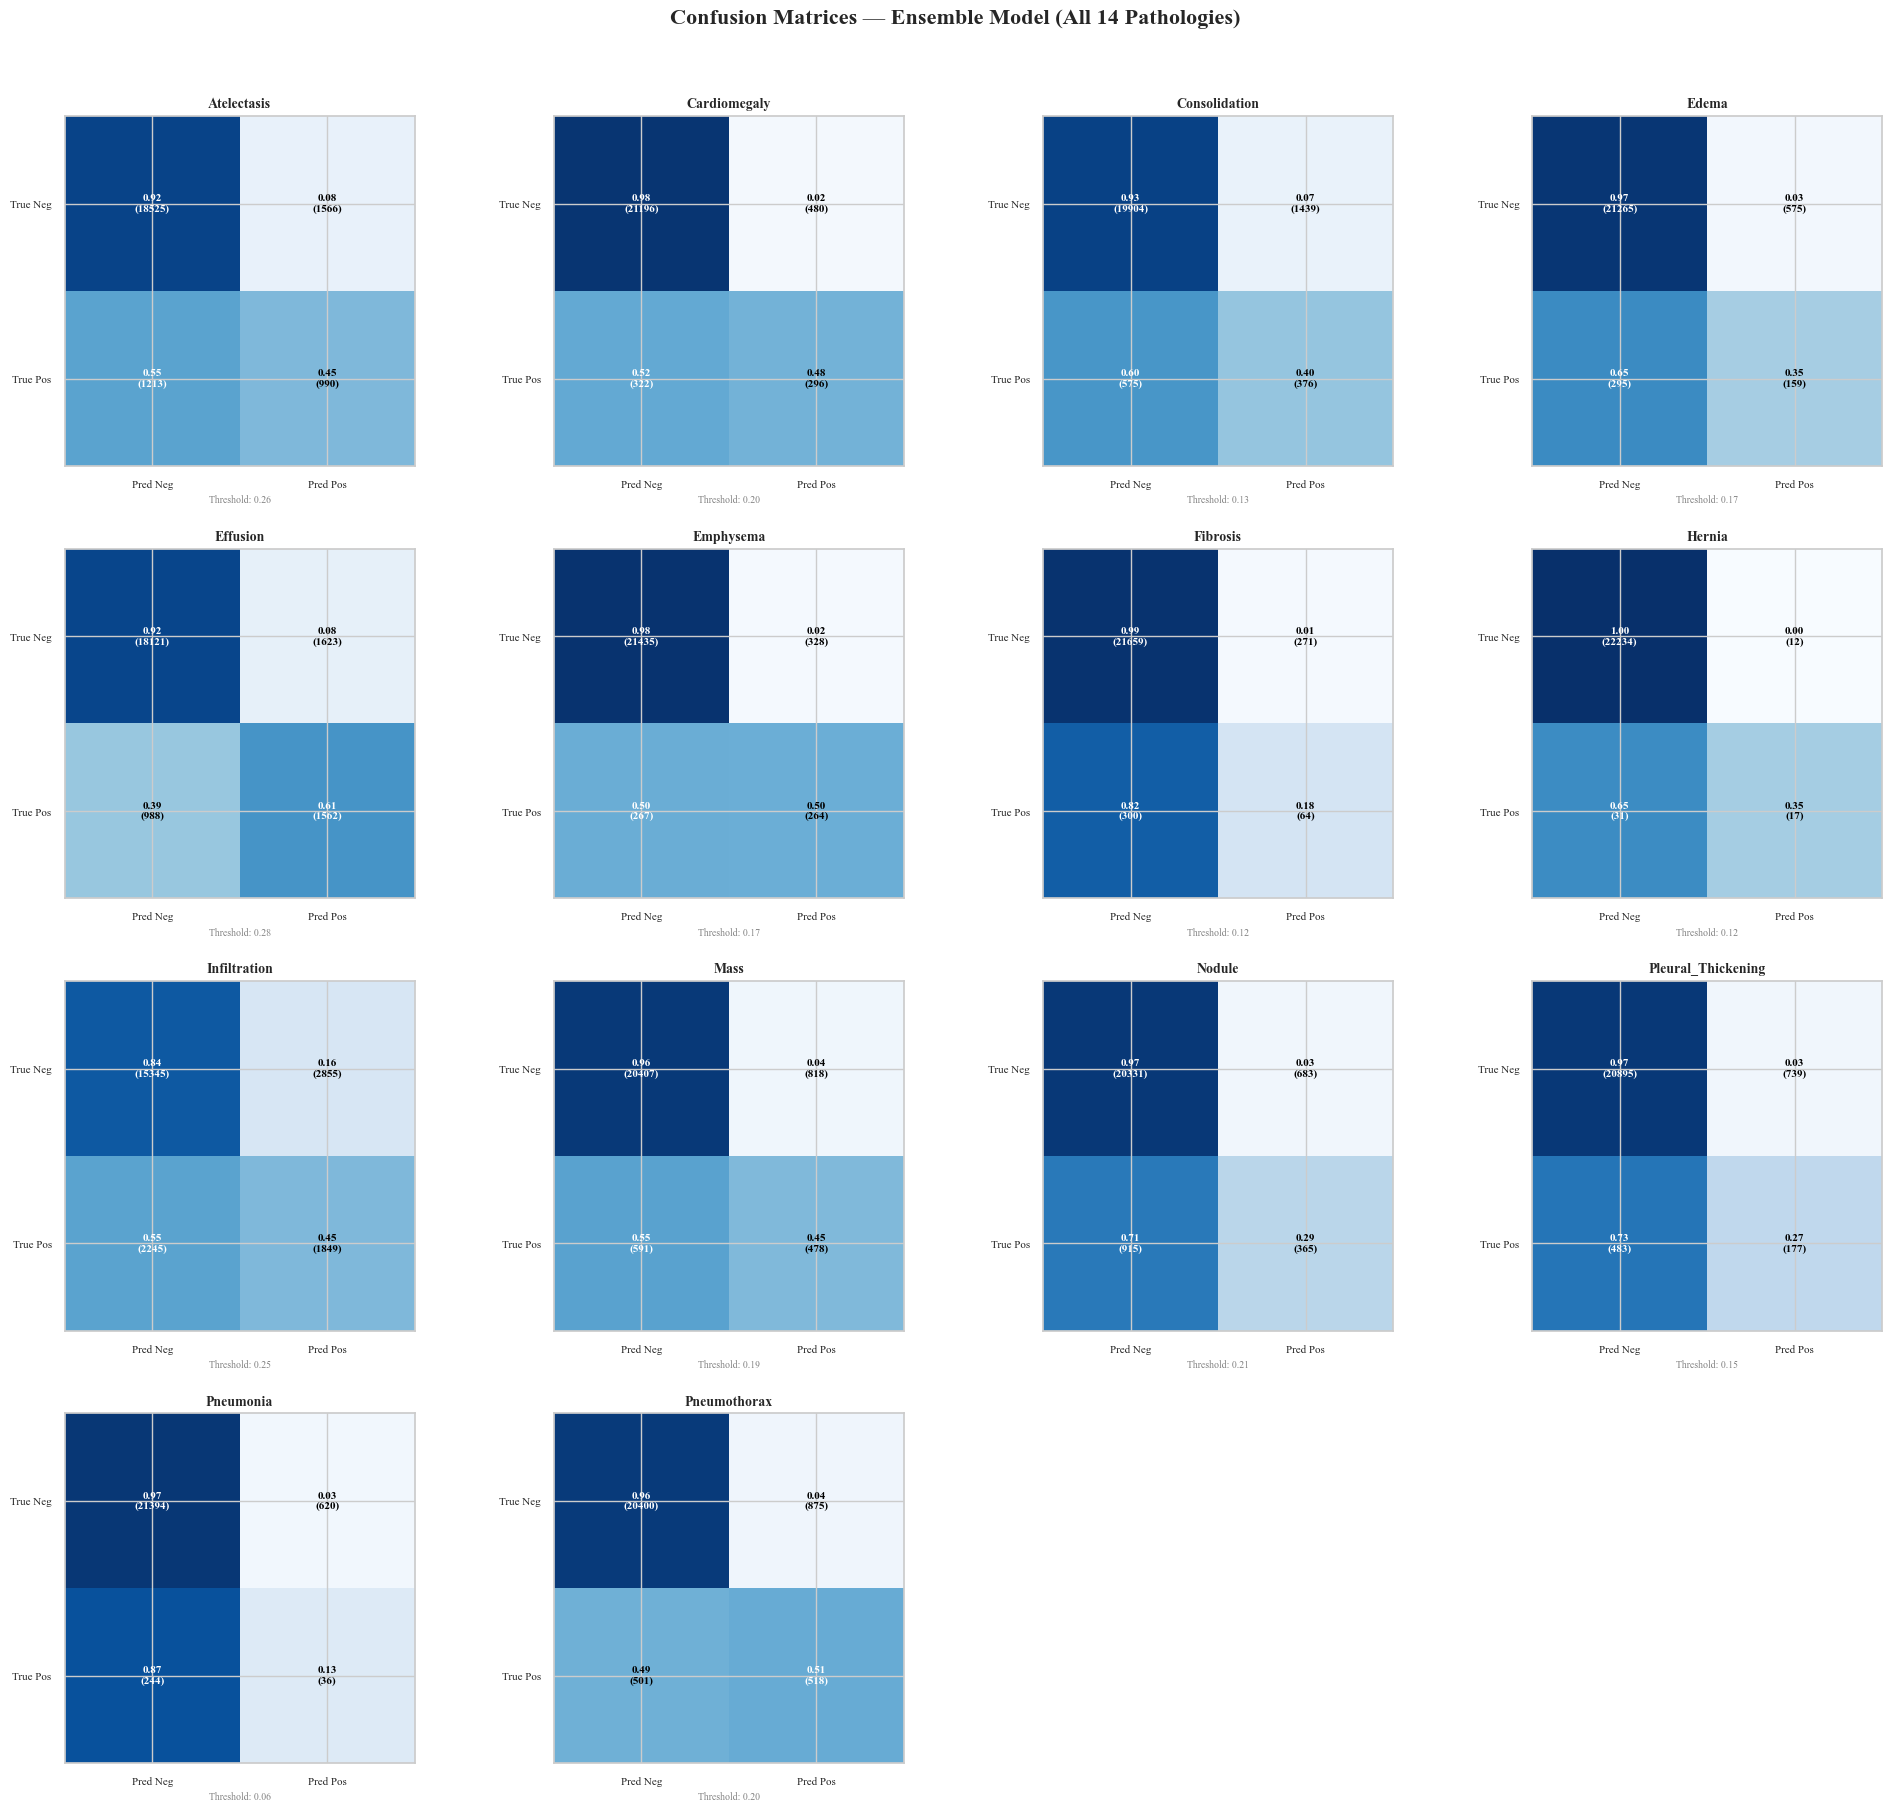

Done.


In [21]:
from sklearn.metrics import confusion_matrix
import numpy as np

print("Generating confusion matrices for all 14 classes...")

# --- Extract optimal thresholds from results_df (before it was string-formatted) ---
# Re-derive from the float results list to avoid parsing strings
thresholds_for_cm = [r['Threshold'] for r in results]

# --- Layout: 4 rows x 4 cols (14 classes + 2 empty) ---
n_classes = len(DISEASES)
n_cols = 4
n_rows = int(np.ceil(n_classes / n_cols))  # = 4

fig = plt.figure(figsize=(20, 18))
fig.suptitle('Confusion Matrices — Ensemble Model (All 14 Pathologies)',
             fontsize=16, fontweight='bold', y=1.01)

for i, disease in enumerate(DISEASES):
    true_labels = ensemble_labels_np[:, i]
    pred_probs  = ensemble_preds_np[:, i]
    thresh      = thresholds_for_cm[i]

    pred_binary = (pred_probs >= thresh).astype(int)
    cm = confusion_matrix(true_labels, pred_binary)

    # Unpack — guaranteed 2x2 since we have both classes in full test set
    tn, fp, fn, tp = cm.ravel()

    # Normalize per row (recall-normalized) so imbalanced classes are readable
    cm_normalized = cm.astype(float)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_normalized = np.divide(cm_normalized, row_sums,
                               where=row_sums != 0)

    ax = fig.add_subplot(n_rows, n_cols, i + 1)

    im = ax.imshow(cm_normalized, interpolation='nearest',
                   cmap='Blues', vmin=0, vmax=1)

    # --- Annotations: show both count and normalized value ---
    raw_counts = [[tn, fp], [fn, tp]]
    for row in range(2):
        for col in range(2):
            norm_val = cm_normalized[row, col]
            count    = raw_counts[row][col]
            color    = 'white' if norm_val > 0.5 else 'black'
            ax.text(col, row,
                    f'{norm_val:.2f}\n({count})',
                    ha='center', va='center',
                    fontsize=8, color=color, fontweight='bold')

    # --- Labels ---
    ax.set_title(disease, fontsize=10, fontweight='bold', pad=6)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred Neg', 'Pred Pos'], fontsize=8)
    ax.set_yticklabels(['True Neg', 'True Pos'], fontsize=8)
    ax.set_xlabel(f'Threshold: {thresh:.2f}', fontsize=7, color='gray')

# --- Hide unused subplots ---
for j in range(n_classes, n_rows * n_cols):
    fig.add_subplot(n_rows, n_cols, j + 1).set_visible(False)

plt.tight_layout()
plt.savefig('ensemble_confusion_matrices.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Done.")

In [22]:
# -----------------------------
# 1) Load bbox metadata (clean)
# -----------------------------
bbox_df = pd.read_csv(BBOX_DIR)
bbox_df.columns = [c.strip() for c in bbox_df.columns]

# NIH columns are typically: Image Index, Finding Label, Bbox [x, y, w, h]
possible_map = {
    'Image Index': ['Image Index'],
    'Finding Label': ['Finding Label', 'Label'],
    'x': ['Bbox [x', 'x'],
    'y': ['y'],
    'w': ['w', 'width'],
    'h': ['h', 'height']
}

resolved = {}
for out_col, candidates in possible_map.items():
    found = None
    for c in candidates:
        if c in bbox_df.columns:
            found = c
            break
    if found is None:
        for col in bbox_df.columns:
            if any(c.lower() in col.lower() for c in candidates):
                found = col
                break
    if found is None:
        raise ValueError(f'Missing required bbox column for {out_col}. Available: {bbox_df.columns.tolist()}')
    resolved[out_col] = found

bbox_df = bbox_df[[resolved['Image Index'], resolved['Finding Label'], resolved['x'], resolved['y'], resolved['w'], resolved['h']]].rename(columns={
    resolved['Image Index']: 'Image Index',
    resolved['Finding Label']: 'Finding Label',
    resolved['x']: 'x',
    resolved['y']: 'y',
    resolved['w']: 'w',
    resolved['h']: 'h'
})

for c in ['x', 'y', 'w', 'h']:
    bbox_df[c] = pd.to_numeric(bbox_df[c], errors='coerce')
bbox_df = bbox_df.dropna(subset=['x', 'y', 'w', 'h']).copy()
bbox_df['Image Index'] = bbox_df['Image Index'].astype(str)
bbox_df['Finding Label'] = bbox_df['Finding Label'].astype(str)

# -----------------------------
# 2) Build complete bbox table from all dataset images
# -----------------------------
# Use the full dataframe mapping so every bbox-annotated image can be resolved to a path.
test_name_to_path = dict(zip(df['Image Index'].astype(str), df['Image_Path']))
test_name_set = set(test_name_to_path.keys())

all_bbox_labeled_images = bbox_df[
    bbox_df['Image Index'].isin(test_name_set)
].copy()

all_bbox_labeled_images = (
    all_bbox_labeled_images[['Image Index', 'Finding Label', 'x', 'y', 'w', 'h']]
    .sort_values(['Finding Label', 'Image Index'])
    .reset_index(drop=True)
)

bbox_label_summary = (
    all_bbox_labeled_images
    .groupby('Finding Label', as_index=False)
    .agg(
        n_bbox=('Image Index', 'size'),
        n_images=('Image Index', 'nunique')
    )
    .sort_values('Finding Label')
    .reset_index(drop=True)
)

print(f"Total bbox annotations (all labels): {len(all_bbox_labeled_images)}")
print(f"Total unique images with bbox annotations: {all_bbox_labeled_images['Image Index'].nunique()}")
display(bbox_label_summary)
display(all_bbox_labeled_images)

# Keep the 14-pathology subset for downstream metric/cam cells.
candidate_bbox = all_bbox_labeled_images[
    all_bbox_labeled_images['Finding Label'].isin(DISEASES)
].copy()

missing_bbox_labels = sorted(set(DISEASES) - set(candidate_bbox['Finding Label']))
if missing_bbox_labels:
    print('Labels with no bbox rows in file:', ', '.join(missing_bbox_labels))

extra_bbox_labels = sorted(set(all_bbox_labeled_images['Finding Label']) - set(DISEASES))
if extra_bbox_labels:
    print('Additional bbox labels not in DISEASES:', ', '.join(extra_bbox_labels))

# -----------------------------
# 3) Pick at least 8 images (unique Image Index), prioritizing label diversity
# -----------------------------
N_IMAGES = 12

# Keep one bbox per image first
one_bbox_per_image = candidate_bbox.drop_duplicates(subset=['Image Index'], keep='first').copy()

# Take one image per label first, then fill remaining slots with any unused images
label_diverse = one_bbox_per_image.drop_duplicates(subset=['Finding Label'], keep='first').copy()

if len(label_diverse) >= N_IMAGES:
    selected_df = label_diverse.head(N_IMAGES).reset_index(drop=True)
else:
    used_images = set(label_diverse['Image Index'])
    fill_df = one_bbox_per_image[~one_bbox_per_image['Image Index'].isin(used_images)]
    needed = N_IMAGES - len(label_diverse)
    selected_df = pd.concat([label_diverse, fill_df.head(needed)], ignore_index=True)

if len(selected_df) < N_IMAGES:
    raise ValueError(
        f'Could only find {len(selected_df)} valid images with bbox and disease labels; expected at least {N_IMAGES}.'
    )

display(selected_df[['Image Index', 'Finding Label', 'x', 'y', 'w', 'h']])

Total bbox annotations (all labels): 984
Total unique images with bbox annotations: 880


,Finding Label,n_bbox,n_images
0,Atelectasis,180,180
1,Cardiomegaly,146,146
2,Effusion,153,153
3,Infiltrate,123,123
4,Mass,85,85
5,Nodule,79,79
6,Pneumonia,120,120
7,Pneumothorax,98,98


,Image Index,Finding Label,x,y,w,h
0,00000072_000.png,Atelectasis,356.503704,567.805291,127.864550,82.353439
1,00000147_001.png,Atelectasis,617.650794,599.229630,100.774603,179.877249
2,00000149_006.png,Atelectasis,603.661017,460.239556,249.491525,90.033898
3,00000181_061.png,Atelectasis,209.898305,568.714132,213.694915,254.915254
4,00000211_010.png,Atelectasis,353.084746,535.087013,101.966102,168.135593
...,...,...,...,...,...,...
979,00029909_003.png,Pneumothorax,167.822222,168.713490,233.244444,89.884444
980,00030111_007.png,Pneumothorax,593.351111,97.033490,157.013333,251.448889
981,00030162_026.png,Pneumothorax,539.875556,268.837934,94.435556,73.955556
982,00030162_029.png,Pneumothorax,621.985185,167.957672,203.716402,159.288889


Labels with no bbox rows in file: Consolidation, Edema, Emphysema, Fibrosis, Hernia, Infiltration, Pleural_Thickening
Additional bbox labels not in DISEASES: Infiltrate


,Image Index,Finding Label,x,y,w,h
0,00000072_000.png,Atelectasis,356.503704,567.805291,127.864550,82.353439
1,00000211_019.png,Cardiomegaly,340.067797,422.779661,501.152542,406.779661
2,00000344_003.png,Effusion,172.373333,230.153490,97.848889,221.866667
3,00000902_001.png,Mass,351.085714,634.988360,88.855026,84.520635
4,00001555_002.png,Nodule,614.400000,808.364021,74.768254,75.851852
5,00000150_002.png,Pneumonia,601.396825,595.978836,215.635979,180.960847
6,00001248_038.png,Pneumothorax,567.805291,94.273016,253.561905,167.957672
7,00000147_001.png,Atelectasis,617.650794,599.229630,100.774603,179.877249
8,00000149_006.png,Atelectasis,603.661017,460.239556,249.491525,90.033898
9,00000181_061.png,Atelectasis,209.898305,568.714132,213.694915,254.915254


In [23]:
class EnsembleWrapper(nn.Module):
    def __init__(self, densenet, swin, efficientnet, resnet):
        super().__init__()
        self.densenet = densenet
        self.swin = swin
        self.efficientnet = efficientnet
        self.resnet = resnet

    def forward(self, x):
        probs_bce    = torch.sigmoid(self.densenet(x))
        probs_focal  = torch.sigmoid(self.swin(x))
        probs_wfocal = torch.sigmoid(self.efficientnet(x))
        probs_resnet = torch.sigmoid(self.resnet(x))

        stacked = torch.stack([probs_bce, probs_focal, probs_wfocal, probs_resnet], dim=0)
        return stacked.mean(dim=0)

ensemble_model = EnsembleWrapper(densenet, swin, efficientnet, resnet)
ensemble_model.eval()
ensemble_model.to(device)

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Ensemble Inference"):
        images = images.to(device)
        ensemble_probs = ensemble_model(images)

        all_preds.append(ensemble_probs.cpu().numpy())
        all_labels.append(labels.numpy())

ensemble_preds_np = np.vstack(all_preds)
ensemble_labels_np = np.vstack(all_labels)

def get_last_conv(model):
    last_conv = None
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            last_conv = module
    return last_conv

target_layers = [
    get_last_conv(ensemble_model.densenet),
    get_last_conv(ensemble_model.efficientnet),
    get_last_conv(ensemble_model.resnet)
]

target_layers = [layer for layer in target_layers if layer is not None]

cam_extractor = GradCAM(model=ensemble_model, target_layers=target_layers)

Ensemble Inference: 100%|██████████| 349/349 [06:34<00:00,  1.13s/it]


In [24]:
# Compute S_loc per class from Grad-CAM and annotated bbox regions.
# S_loc = sum(CAM inside bbox) / sum(CAM over full map)
MAX_BBOX_PER_CLASS = None  # Set to an int (e.g., 100) for faster approximate evaluation.

sloc_rows = []
bbox_eval_df = candidate_bbox.drop_duplicates(
    subset=['Image Index', 'Finding Label', 'x', 'y', 'w', 'h']
).copy()

for disease in DISEASES:
    class_rows = bbox_eval_df[bbox_eval_df['Finding Label'] == disease].copy()
    if MAX_BBOX_PER_CLASS is not None and len(class_rows) > MAX_BBOX_PER_CLASS:
        class_rows = class_rows.sample(n=MAX_BBOX_PER_CLASS, random_state=42)

    for _, row in tqdm(
        class_rows.iterrows(),
        total=len(class_rows),
        desc=f'S_loc {disease}',
        leave=False
    ):
        image_name = str(row['Image Index'])
        image_path = test_name_to_path.get(image_name)
        if image_path is None:
            continue

        image_bgr = cv2.imread(image_path)
        if image_bgr is None:
            continue

        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        input_tensor = base_transform(image=image_rgb)['image'].unsqueeze(0).to(device)
        class_idx = DISEASES.index(disease)

        grayscale_cam = cam_extractor(
            input_tensor=input_tensor,
            targets=[ClassifierOutputTarget(class_idx)]
        )[0]

        h_img, w_img = image_rgb.shape[:2]
        x, y, w_box, h_box = float(row['x']), float(row['y']), float(row['w']), float(row['h'])

        # NIH bbox coordinates can occasionally be in 1024x1024 reference frame.
        if (x + w_box > w_img) or (y + h_box > h_img):
            sx, sy = w_img / 1024.0, h_img / 1024.0
            x, y, w_box, h_box = x * sx, y * sy, w_box * sx, h_box * sy

        x1, y1 = int(max(0, x)), int(max(0, y))
        x2, y2 = int(min(w_img - 1, x + w_box)), int(min(h_img - 1, y + h_box))
        if x2 <= x1 or y2 <= y1:
            continue

        cam_h, cam_w = grayscale_cam.shape
        sx_cam, sy_cam = cam_w / w_img, cam_h / h_img

        cx1 = int(np.clip(np.floor(x1 * sx_cam), 0, cam_w - 1))
        cy1 = int(np.clip(np.floor(y1 * sy_cam), 0, cam_h - 1))
        cx2 = int(np.clip(np.ceil(x2 * sx_cam), 0, cam_w - 1))
        cy2 = int(np.clip(np.ceil(y2 * sy_cam), 0, cam_h - 1))

        bbox_mask = np.zeros_like(grayscale_cam, dtype=bool)
        bbox_mask[cy1:cy2 + 1, cx1:cx2 + 1] = True

        total_sum = float(grayscale_cam.sum())
        if total_sum <= 1e-12:
            continue

        inside_sum = float(grayscale_cam[bbox_mask].sum())
        s_loc = inside_sum / total_sum

        sloc_rows.append({
            'Image Index': image_name,
            'Finding Label': disease,
            'inside_sum': inside_sum,
            'total_sum': total_sum,
            'S_loc': s_loc
        })

sloc_df = pd.DataFrame(sloc_rows)
if sloc_df.empty:
    raise ValueError('No valid Grad-CAM + bbox pairs found to compute S_loc.')

sloc_summary = (
    sloc_df.groupby('Finding Label', as_index=False)
    .agg(
        n_samples=('S_loc', 'size'),
        n_images=('Image Index', 'nunique'),
        S_loc_mean=('S_loc', 'mean'),
        S_loc_std=('S_loc', 'std'),
        S_loc_median=('S_loc', 'median'),
        inside_sum=('inside_sum', 'sum'),
        total_sum=('total_sum', 'sum')
    )
)
sloc_summary['S_loc_pooled'] = sloc_summary['inside_sum'] / sloc_summary['total_sum']

# Keep all classes in final table, even those with no bbox samples in this split.
all_classes_df = pd.DataFrame({'Finding Label': DISEASES})
sloc_summary = all_classes_df.merge(sloc_summary, on='Finding Label', how='left')
sloc_summary[['n_samples', 'n_images']] = sloc_summary[['n_samples', 'n_images']].fillna(0).astype(int)
sloc_summary = sloc_summary.sort_values('S_loc_pooled', ascending=False, na_position='last').reset_index(drop=True)

display(
    sloc_summary[
        ['Finding Label', 'n_samples', 'n_images', 'S_loc_mean', 'S_loc_std', 'S_loc_median', 'S_loc_pooled']
    ].style.format({
        'S_loc_mean': '{:.4f}',
        'S_loc_std': '{:.4f}',
        'S_loc_median': '{:.4f}',
        'S_loc_pooled': '{:.4f}'
    })
)

missing_classes = sloc_summary.loc[sloc_summary['n_samples'] == 0, 'Finding Label'].tolist()
if missing_classes:
    print('No bbox samples in eval split for:', ', '.join(missing_classes))

S_loc Atelectasis:   0%|          | 0/180 [00:00<?, ?it/s]

,Finding Label,n_samples,n_images,S_loc_mean,S_loc_std,S_loc_median,S_loc_pooled
0,Cardiomegaly,146,146,0.3885,0.0947,0.3992,0.3807
1,Pneumonia,120,120,0.1338,0.1351,0.0958,0.1337
2,Effusion,153,153,0.1083,0.0854,0.0898,0.1029
3,Pneumothorax,98,98,0.0853,0.0974,0.0474,0.0801
4,Mass,85,85,0.0783,0.1091,0.0367,0.0723
5,Atelectasis,180,180,0.0652,0.0642,0.0456,0.0613
6,Nodule,79,79,0.0111,0.0076,0.0094,0.0108
7,Consolidation,0,0,nan,nan,nan,nan
8,Edema,0,0,nan,nan,nan,nan
9,Emphysema,0,0,nan,nan,nan,nan


No bbox samples in eval split for: Consolidation, Edema, Emphysema, Fibrosis, Hernia, Infiltration, Pleural_Thickening


,Image Index,Finding Label,inside_ratio,peak_inside,pred_prob
0,00019271_064.png,Atelectasis,0.484355,True,0.749075
1,00008339_010.png,Cardiomegaly,0.542419,True,0.405241
2,00012973_005.png,Effusion,0.493988,True,0.685458
3,00021179_011.png,Mass,0.651631,True,0.760021
4,00022084_000.png,Pneumonia,0.435262,True,0.046238
5,00016429_015.png,Pneumothorax,0.543903,True,0.863347
6,00014253_042.png,Atelectasis,0.307060,False,0.453833
7,00017511_006.png,Cardiomegaly,0.324448,True,0.471081
8,00016522_023.png,Effusion,0.324050,False,0.291200
9,00018623_001.png,Mass,0.335409,True,0.543106


Class distribution in selected examples:
Finding Label
Atelectasis     2
Cardiomegaly    2
Effusion        2
Mass            2
Pneumonia       2
Pneumothorax    2
Name: count, dtype: int64


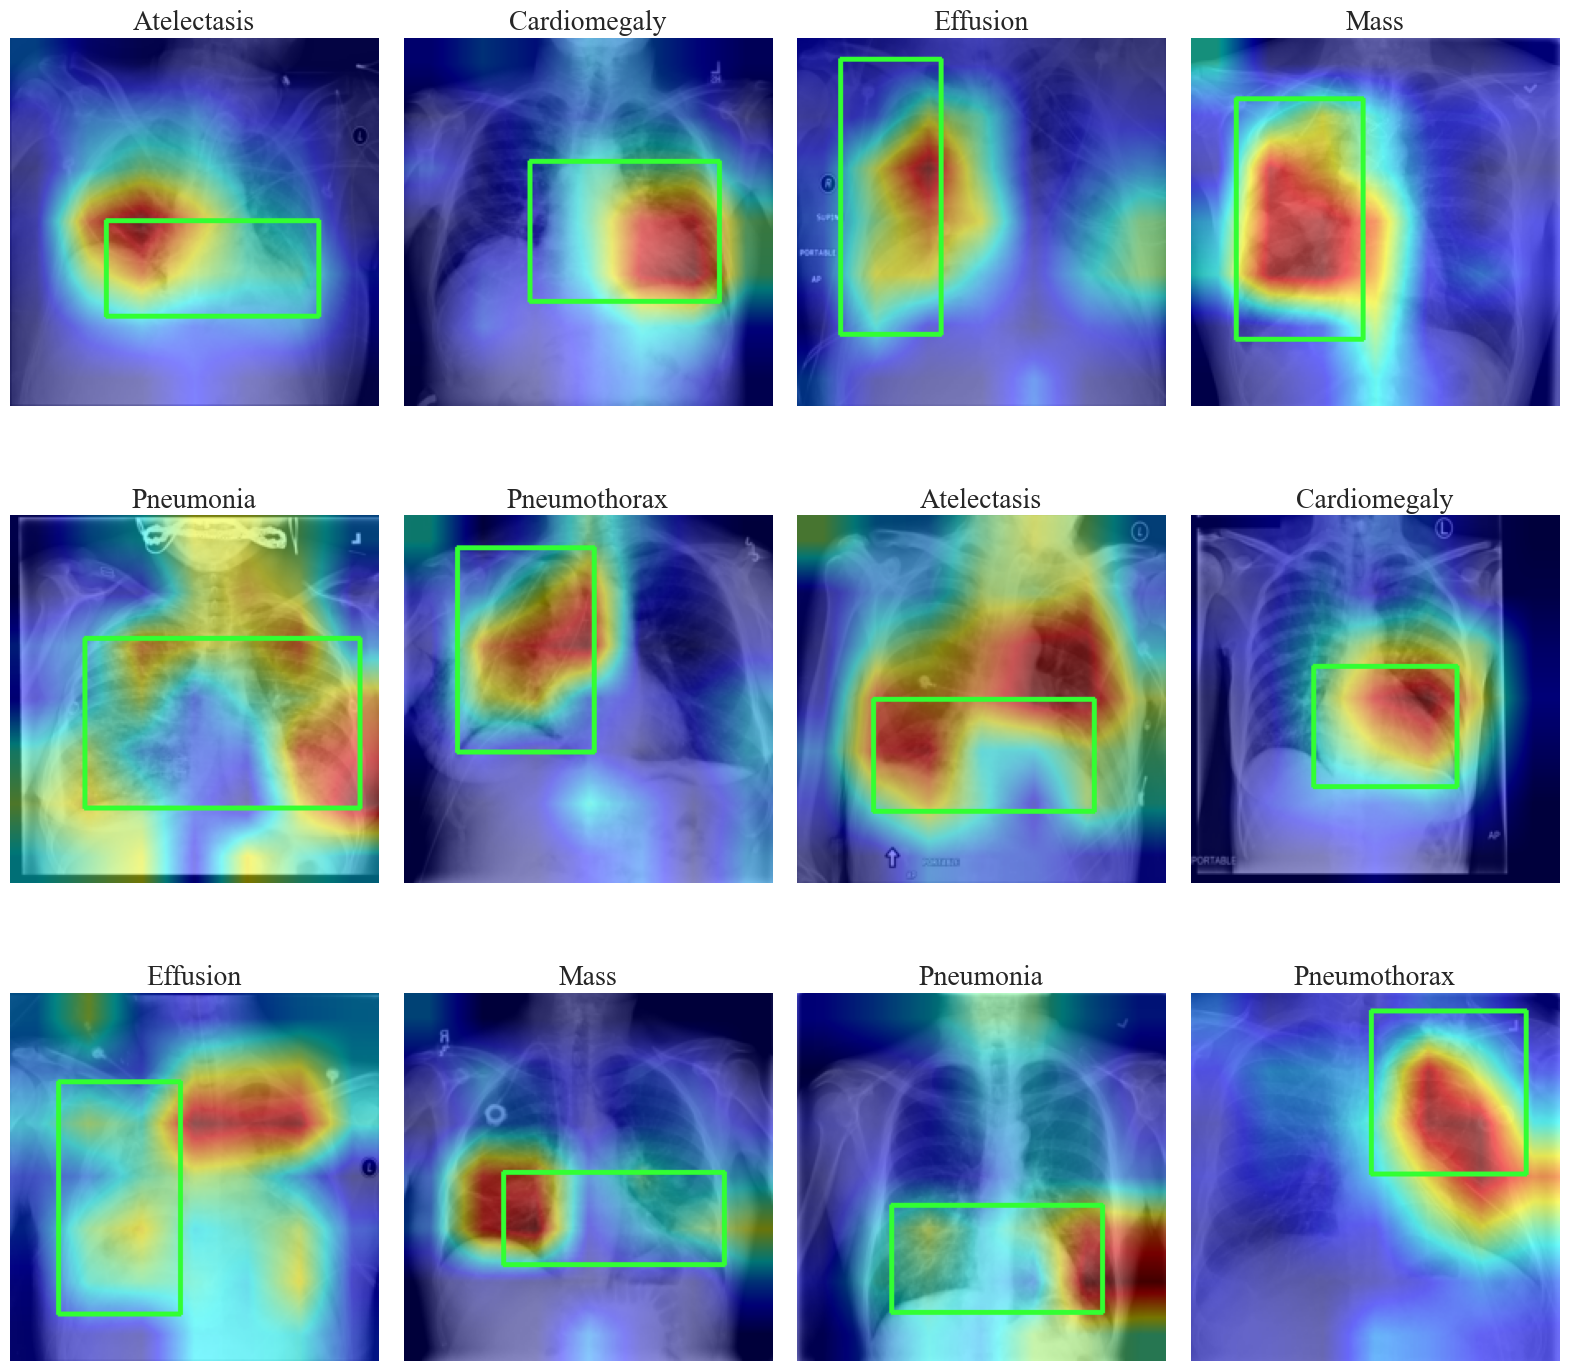

In [25]:
TOP_PERCENTILE = 70             # top CAM intensity to define "high" points
MIN_INSIDE_RATIO = 0.40         # at least 40% of high points inside bbox
REQUIRE_PEAK_INSIDE = False     # also require global CAM peak inside bbox

selected_examples = []
used_images = set()
selected_per_class = {d: 0 for d in DISEASES}

# Shuffle candidates within each class for fairer sampling across diseases
class_to_rows = {}
for disease in DISEASES:
    class_rows = one_bbox_per_image[one_bbox_per_image['Finding Label'] == disease].copy()
    if len(class_rows) > 0:
        class_rows = class_rows.sample(frac=1.0, random_state=42).reset_index(drop=True)
    class_to_rows[disease] = class_rows

class_ptr = {d: 0 for d in DISEASES}


def build_example_if_valid(row, top_percentile, min_inside_ratio, require_peak_inside):
    image_name = row['Image Index']
    target_label = row['Finding Label']
    image_path = test_name_to_path.get(image_name)

    if image_path is None:
        return None

    image_bgr = cv2.imread(image_path)
    if image_bgr is None:
        return None

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    input_tensor = base_transform(image=image_rgb)['image'].unsqueeze(0).to(device)
    class_idx = DISEASES.index(target_label)

    with torch.no_grad():
        pred_logit = swin(input_tensor)[0, class_idx].item()
    pred_prob = 1 / (1 + np.exp(-pred_logit))

    grayscale_cam = cam_extractor(
        input_tensor=input_tensor,
        targets=[ClassifierOutputTarget(class_idx)]
    )[0]

    # Coordinate scaling and Bounding Box logic
    h_img, w_img = image_rgb.shape[:2]
    x, y, w_box, h_box = float(row['x']), float(row['y']), float(row['w']), float(row['h'])

    # NIH bbox can occasionally be defined in a 1024x1024 reference frame
    if (x + w_box > w_img) or (y + h_box > h_img):
        sx, sy = w_img / 1024.0, h_img / 1024.0
        x, y, w_box, h_box = x * sx, y * sy, w_box * sx, h_box * sy

    x1, y1 = int(max(0, x)), int(max(0, y))
    x2, y2 = int(min(w_img - 1, x + w_box)), int(min(h_img - 1, y + h_box))

    if x2 <= x1 or y2 <= y1:
        return None

    # Build high-CAM mask
    high_thr = np.percentile(grayscale_cam, top_percentile)
    high_mask = grayscale_cam >= high_thr
    if high_mask.sum() == 0:
        return None

    # Map bbox to CAM resolution for overlap calculation
    cam_h, cam_w = grayscale_cam.shape
    sx_cam, sy_cam = cam_w / w_img, cam_h / h_img

    cx1 = int(np.clip(np.floor(x1 * sx_cam), 0, cam_w - 1))
    cy1 = int(np.clip(np.floor(y1 * sy_cam), 0, cam_h - 1))
    cx2 = int(np.clip(np.ceil(x2 * sx_cam), 0, cam_w - 1))
    cy2 = int(np.clip(np.ceil(y2 * sy_cam), 0, cam_h - 1))

    bbox_mask = np.zeros_like(high_mask, dtype=bool)
    bbox_mask[cy1:cy2 + 1, cx1:cx2 + 1] = True

    inside_ratio = (high_mask & bbox_mask).sum() / high_mask.sum()
    peak_y, peak_x = np.unravel_index(np.argmax(grayscale_cam), grayscale_cam.shape)
    peak_inside = bool(bbox_mask[peak_y, peak_x])

    is_valid = inside_ratio >= min_inside_ratio
    if require_peak_inside:
        is_valid = is_valid and peak_inside
    if not is_valid:
        return None

    image_float = image_rgb.astype(np.float32) / 255.0
    cam_overlay = show_cam_on_image(image_float, grayscale_cam, use_rgb=True, image_weight=0.55)
    cv2.rectangle(cam_overlay, (x1, y1), (x2, y2), (50, 255, 50), 2)

    return {
        'Image Index': image_name,
        'Finding Label': target_label,
        'x': x,
        'y': y,
        'w': w_box,
        'h': h_box,
        'pred_prob': pred_prob,
        'inside_ratio': inside_ratio,
        'peak_inside': peak_inside,
        'cam_overlay': cam_overlay
    }


# Multi-pass strategy: first strict and highly diverse, then relaxed to fill quota.
selection_passes = [
    {'top_percentile': TOP_PERCENTILE, 'min_inside_ratio': MIN_INSIDE_RATIO, 'require_peak_inside': REQUIRE_PEAK_INSIDE, 'max_per_class': 1},
    {'top_percentile': max(55, TOP_PERCENTILE - 10), 'min_inside_ratio': max(0.25, MIN_INSIDE_RATIO - 0.10), 'require_peak_inside': False, 'max_per_class': 2},
    {'top_percentile': max(45, TOP_PERCENTILE - 20), 'min_inside_ratio': max(0.15, MIN_INSIDE_RATIO - 0.20), 'require_peak_inside': False, 'max_per_class': 3},
]

for cfg in selection_passes:
    if len(selected_examples) >= N_IMAGES:
        break

    made_progress = True
    while made_progress and len(selected_examples) < N_IMAGES:
        made_progress = False

        for disease in DISEASES:
            if len(selected_examples) >= N_IMAGES:
                break

            if selected_per_class[disease] >= cfg['max_per_class']:
                continue

            rows = class_to_rows[disease]
            while class_ptr[disease] < len(rows):
                row = rows.iloc[class_ptr[disease]]
                class_ptr[disease] += 1

                if row['Image Index'] in used_images:
                    continue

                example = build_example_if_valid(
                    row,
                    top_percentile=cfg['top_percentile'],
                    min_inside_ratio=cfg['min_inside_ratio'],
                    require_peak_inside=cfg['require_peak_inside']
                )
                if example is None:
                    continue

                selected_examples.append(example)
                used_images.add(example['Image Index'])
                selected_per_class[disease] += 1
                made_progress = True
                break

if len(selected_examples) == 0:
    raise ValueError('No images met the Grad-CAM-inside-bbox criterion. Try lowering MIN_INSIDE_RATIO or TOP_PERCENTILE.')

if len(selected_examples) < N_IMAGES:
    print(f'Warning: only found {len(selected_examples)} images matching CAM-inside-bbox criteria (target={N_IMAGES}).')

selected_df = pd.DataFrame([{k: v for k, v in ex.items() if k != 'cam_overlay'} for ex in selected_examples])
display(selected_df[['Image Index', 'Finding Label', 'inside_ratio', 'peak_inside', 'pred_prob']])
print('Class distribution in selected examples:')
print(selected_df['Finding Label'].value_counts())

n_to_plot = len(selected_examples)
cols = 4
rows = int(np.ceil(n_to_plot / cols))

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 5 * rows))
axes = np.array(axes).reshape(-1)

for i, ex in enumerate(selected_examples):
    ax = axes[i]
    ax.imshow(ex['cam_overlay'])
    ax.set_title(f"{ex['Finding Label']}")
    ax.axis('off')

for j in range(n_to_plot, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [15]:
cols_to_show = ['Finding Label', 'n_samples', 'n_images', 'S_loc_mean', 'S_loc_std', 'S_loc_median', 'S_loc_pooled']
print(sloc_summary[cols_to_show].to_string(index=False, float_format=lambda x: f'{x:.4f}'))

     Finding Label  n_samples  n_images  S_loc_mean  S_loc_std  S_loc_median  S_loc_pooled
      Cardiomegaly         56        56      0.3701     0.1081        0.3670        0.3607
         Pneumonia         44        44      0.1179     0.1396        0.0651        0.1238
          Effusion         54        54      0.1064     0.0880        0.0892        0.1001
              Mass         26        26      0.0903     0.1257        0.0344        0.0800
       Atelectasis         55        55      0.0706     0.0736        0.0453        0.0654
      Pneumothorax         30        30      0.0545     0.0608        0.0447        0.0505
            Nodule         32        32      0.0101     0.0069        0.0090        0.0098
     Consolidation          0         0         NaN        NaN           NaN           NaN
             Edema          0         0         NaN        NaN           NaN           NaN
         Emphysema          0         0         NaN        NaN           NaN           NaN

In [38]:
# Failure-case Grad-CAM analysis using models already loaded earlier in the notebook.
# Expected available variables: densenet, resnet, efficientnet, swin, base_transform,
# test_df, ensemble_preds_np, ensemble_labels_np, device.


def unwrap_backbone(model):
    return model.model if hasattr(model, "model") else model


def swin_reshape_transform(tensor):
    """Convert Swin/ViT activations to [B, C, H, W] for Grad-CAM."""
    if tensor.ndim == 4:
        # timm Swin blocks often expose channels-last features: [B, H, W, C]
        if tensor.shape[-1] > tensor.shape[1]:
            return tensor.permute(0, 3, 1, 2)
        return tensor

    if tensor.ndim != 3:
        raise ValueError(f"Unexpected Swin activation shape: {tuple(tensor.shape)}")

    bsz, num_tokens, channels = tensor.shape
    hw = int(np.sqrt(num_tokens))

    # Some transformer backbones include a class token in token sequences.
    if hw * hw != num_tokens and num_tokens > 1:
        hw = int(np.sqrt(num_tokens - 1))
        if hw * hw == (num_tokens - 1):
            tensor = tensor[:, 1:, :]
            num_tokens = tensor.shape[1]

    if hw * hw != num_tokens:
        raise ValueError(f"Cannot infer square feature map from token count={num_tokens}")

    return tensor.reshape(bsz, hw, hw, channels).permute(0, 3, 1, 2)


def get_efficientnet_target_layer(backbone):
    """Resolve the final feature layer for different timm EfficientNet variants."""
    if hasattr(backbone, "features"):
        return backbone.features[-1]
    if hasattr(backbone, "blocks"):
        return backbone.blocks[-1]
    if hasattr(backbone, "conv_head"):
        return backbone.conv_head
    raise AttributeError("Could not resolve EfficientNet target layer.")

In [39]:
# Build per-model Grad-CAM extractors from the existing ensemble members.

def build_gradcam_extractors():
    models = {
        "densenet": densenet,
        "resnet": resnet,
        "efficientnet": efficientnet,
        "swin": swin,
    }

    for model in models.values():
        model.eval()

    dense_backbone = unwrap_backbone(models["densenet"])
    resnet_backbone = unwrap_backbone(models["resnet"])
    efficientnet_backbone = unwrap_backbone(models["efficientnet"])
    swin_backbone = unwrap_backbone(models["swin"])

    extractors = {
        "densenet": GradCAM(
            model=models["densenet"],
            target_layers=[dense_backbone.features.denseblock4],
        ),
        "resnet": GradCAM(
            model=models["resnet"],
            target_layers=[resnet_backbone.layer4[-1]],
        ),
        "efficientnet": GradCAM(
            model=models["efficientnet"],
            target_layers=[get_efficientnet_target_layer(efficientnet_backbone)],
        ),
        "swin": GradCAM(
            model=models["swin"],
            # Use the last norm in the final stage; keeps semantic focus while preserving spatial tokens.
            target_layers=[swin_backbone.layers[-1].blocks[-1].norm1],
            reshape_transform=swin_reshape_transform,
        ),
    }
    return extractors


def release_gradcam_extractors(extractors):
    """Release hooks to avoid accumulating handles across reruns."""
    for extractor in extractors.values():
        extractor.activations_and_grads.release()

In [51]:
# -----------------------------
# 5) Failure-case mining
# -----------------------------
def select_failure_indices(pred_probs, true_labels, class_idx, top_k=2, fp_thr=0.70, fn_thr=0.30):
    """Return top-k FP and FN indices for one class under fixed confidence thresholds.

    If strict threshold-based candidates are missing, fall back to the most FP-like
    and FN-like samples so plotting can still show one case per class.
    """
    probs = pred_probs[:, class_idx]
    labels = true_labels[:, class_idx].astype(int)

    neg_indices = np.where(labels == 0)[0]
    pos_indices = np.where(labels == 1)[0]

    fp_candidates = np.where((probs > fp_thr) & (labels == 0))[0]
    fn_candidates = np.where((probs < fn_thr) & (labels == 1))[0]

    # Fallbacks guarantee coverage when no sample crosses the strict threshold.
    if len(fp_candidates) == 0 and top_k > 0:
        fp_candidates = neg_indices
    if len(fn_candidates) == 0 and top_k > 0:
        fn_candidates = pos_indices

    # Most confident FP = highest predicted probabilities among true negatives.
    fp_sorted = fp_candidates[np.argsort(probs[fp_candidates])[::-1]] if len(fp_candidates) > 0 else np.array([], dtype=int)
    # Most confident FN = lowest predicted probabilities among true positives.
    fn_sorted = fn_candidates[np.argsort(probs[fn_candidates])] if len(fn_candidates) > 0 else np.array([], dtype=int)

    return fp_sorted[:top_k], fn_sorted[:top_k]


def build_failure_case_table(test_df, pred_probs, true_labels, class_order, top_k=2, fp_thr=0.70, fn_thr=0.30):
    """Build per-class case metadata for plotting and Grad-CAM computation."""
    if len(test_df) != pred_probs.shape[0]:
        raise ValueError(
            f"Length mismatch: test_df={len(test_df)}, predictions={pred_probs.shape[0]}. "
            "Ensure predictions were produced from test_df with shuffle=False."
        )

    case_dict = {}
    for disease, class_idx in class_order:
        fp_indices, fn_indices = select_failure_indices(
            pred_probs,
            true_labels,
            class_idx,
            top_k=top_k,
            fp_thr=fp_thr,
            fn_thr=fn_thr,
        )

        def make_case(row_idx, error_type):
            return {
                "dataset_idx": int(row_idx),
                "image_path": str(test_df.iloc[row_idx]["Image_Path"]),
                "disease": disease,
                "class_idx": class_idx,
                "error_type": error_type,
                "pred_prob": float(pred_probs[row_idx, class_idx]),
                "true_label": int(true_labels[row_idx, class_idx]),
            }

        case_dict[disease] = {
            "FP": [make_case(i, "False Positive") for i in fp_indices],
            "FN": [make_case(i, "False Negative") for i in fn_indices],
        }

    return case_dict

In [62]:
# Grad-CAM + visualization helpers.

def load_image_and_tensor(image_path, transform, device):
    """Load RGB image and transformed tensor for model inference/Grad-CAM."""
    image_rgb = np.array(Image.open(image_path).convert("RGB"))
    input_tensor = transform(image=image_rgb)["image"].unsqueeze(0).to(device)
    return image_rgb, input_tensor


def normalize_cam(cam, eps=1e-8):
    """Robustly normalize a CAM map to [0, 1] while suppressing weak global haze."""
    cam = np.maximum(cam.astype(np.float32), 0.0)
    high = np.percentile(cam, 99.5)
    if high > eps:
        cam = np.clip(cam / high, 0.0, 1.0)

    floor = np.percentile(cam, 25.0)
    cam = cam - floor
    cam = np.clip(cam, 0.0, None)

    peak = cam.max()
    if peak > eps:
        cam = cam / peak
    return cam


def sharpen_cam(cam, focus_percentile=82.0, eps=1e-8):
    """Keep only the strongest CAM regions so hotspots are spatially focused."""
    cam = np.clip(cam.astype(np.float32), 0.0, 1.0)
    thr = float(np.percentile(cam, focus_percentile))
    cam = np.clip((cam - thr) / max(1.0 - thr, eps), 0.0, 1.0)
    return cam


def compute_ensemble_gradcam(
    image_tensor,
    image_hw,
    class_idx,
    extractors,
    model_weights=None,
    focus_percentile=82.0,
):
    """Average Grad-CAM maps from all ensemble members at image resolution."""
    out_h, out_w = image_hw
    per_model_cams = []

    for model_name, extractor in extractors.items():
        cam = extractor(
            input_tensor=image_tensor,
            targets=[ClassifierOutputTarget(class_idx)],
            eigen_smooth=True,
            aug_smooth=False,
        )[0]

        cam_resized = cv2.resize(cam, (out_w, out_h), interpolation=cv2.INTER_CUBIC)
        cam_resized = normalize_cam(cam_resized)

        weight = 1.0 if model_weights is None else float(model_weights.get(model_name, 1.0))
        per_model_cams.append((weight, cam_resized))

    if not per_model_cams:
        raise ValueError("No Grad-CAM extractors were provided.")

    weight_sum = sum(w for w, _ in per_model_cams)
    avg_cam = sum(w * cam for w, cam in per_model_cams) / max(weight_sum, 1e-8)
    avg_cam = normalize_cam(avg_cam)
    avg_cam = sharpen_cam(avg_cam, focus_percentile=focus_percentile)
    return avg_cam


def overlay_heatmap(image_rgb, heatmap, cmap_name="turbo", alpha=0.45, strength=1.0):
    """Overlay normalized heatmap over image."""
    image_float = image_rgb.astype(np.float32) / 255.0
    heatmap_rgb = plt.get_cmap(cmap_name)(heatmap)[..., :3]
    alpha_eff = float(np.clip(alpha * strength, 0.0, 1.0))
    overlay = (1.0 - alpha_eff) * image_float + alpha_eff * heatmap_rgb
    return np.clip(overlay, 0.0, 1.0)


def draw_failure_figure(case_dict, class_order, extractors, transform, device, save_path, dpi=400, cmap_name="turbo", alpha=0.65):
    """Create a 2xN figure: one FP (row 1) and one FN (row 2) per class."""
    save_dir = os.path.dirname(save_path)
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    ordered_diseases = [d for d, _ in class_order]
    n_cols = max(1, len(ordered_diseases))

    norm = plt.Normalize(vmin=0.0, vmax=1.0)
    scalar_mappable = plt.cm.ScalarMappable(norm=norm, cmap=plt.get_cmap(cmap_name))

    fig, axes = plt.subplots(
        nrows=2,
        ncols=n_cols,
        figsize=(4.4 * n_cols, 8.2),
        squeeze=False,
    )

    for col_idx, disease in enumerate(ordered_diseases):
        fp_cases = case_dict[disease]["FP"]
        fn_cases = case_dict[disease]["FN"]

        row_specs = [
            (0, fp_cases, "False Positive", "FP"),
            (1, fn_cases, "False Negative", "FN"),
        ]

        for row_idx, cases, error_label, short_label in row_specs:
            ax = axes[row_idx, col_idx]

            if len(cases) > 0:
                case = cases[0]
                image_rgb, input_tensor = load_image_and_tensor(case["image_path"], transform, device)
                heatmap = compute_ensemble_gradcam(
                    image_tensor=input_tensor,
                    image_hw=image_rgb.shape[:2],
                    class_idx=case["class_idx"],
                    extractors=extractors,
                )
                strength = 0.35 + 0.65 * float(case["pred_prob"])
                overlay = overlay_heatmap(image_rgb, heatmap, cmap_name=cmap_name, alpha=alpha, strength=strength)
                ax.imshow(overlay)
                ax.set_title(
                    f"{disease} | {error_label}\np={case['pred_prob']:.2f} | y={case['true_label']}",
                )
            else:
                ax.set_facecolor("whitesmoke")
                ax.text(0.5, 0.5, f"No {short_label} case", ha="center", va="center")
                ax.set_title(f"{disease} | {error_label}")

            ax.axis("off")

    axes[0, 0].text(
        -0.12,
        0.5,
        "False Positive",
        transform=axes[0, 0].transAxes,
        rotation=90,
        ha="center",
        va="center",
        fontweight="bold",
    )
    axes[1, 0].text(
        -0.12,
        0.5,
        "False Negative",
        transform=axes[1, 0].transAxes,
        rotation=90,
        ha="center",
        va="center",
        fontweight="bold",
    )


    fig.subplots_adjust(left=0.06, right=0.91, top=0.90, bottom=0.05, wspace=0.10, hspace=0.25)
    fig.savefig(save_path, dpi=dpi, facecolor="white")
    plt.show()
    return save_path

Infiltration: FP=1, FN=1
Pneumonia: FP=1, FN=1
Nodule: FP=1, FN=1
Fibrosis: FP=1, FN=1


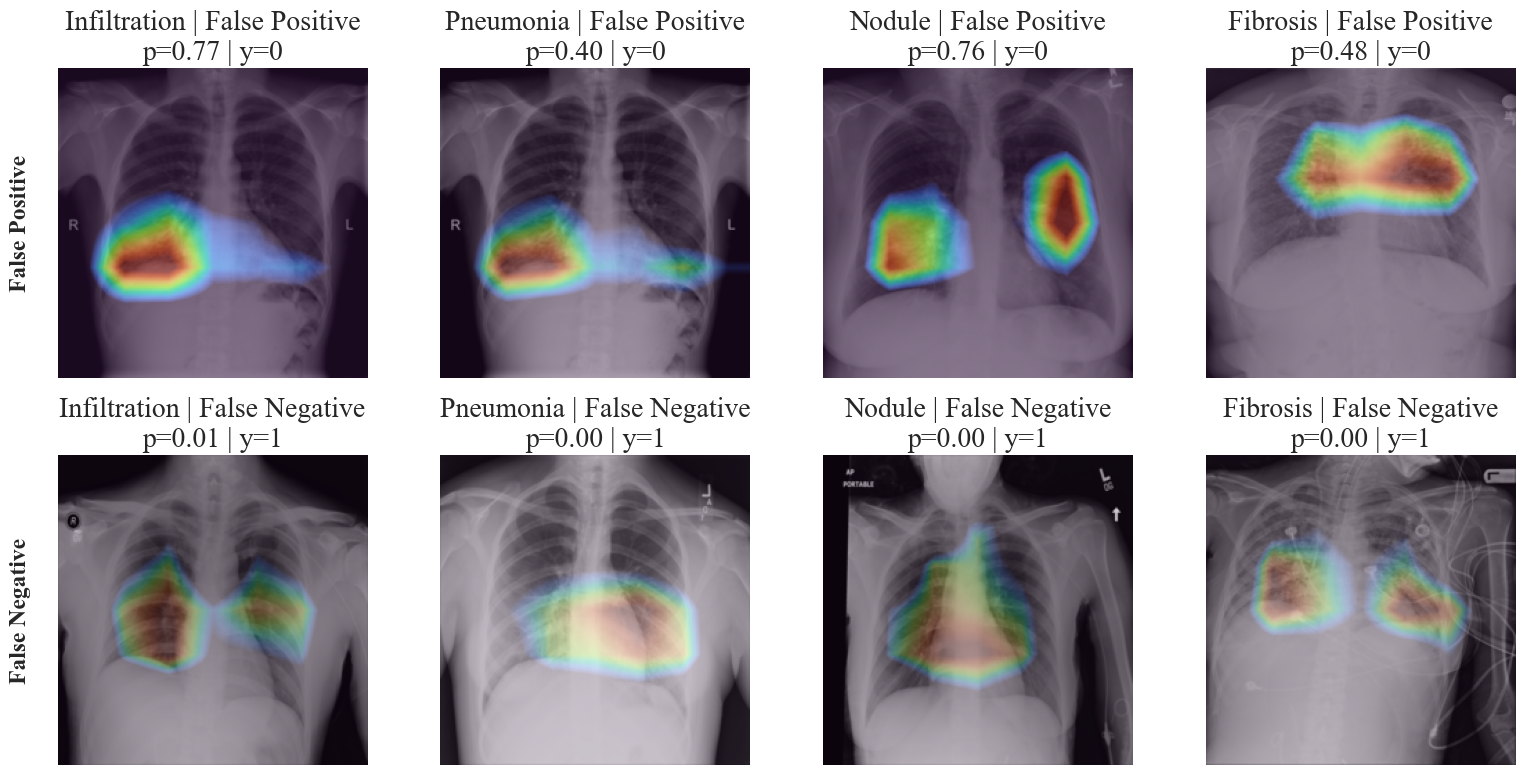

Saved failure-case Grad-CAM figure to: ../artifacts/inference_analysis/failure_case_analysis_gradcam.png


In [63]:
# Run failure-case pipeline using existing notebook objects.

class_order = [
    ("Infiltration", 8),
    ("Pneumonia", 12),
    ("Nodule", 10),
    ("Fibrosis", 6),
]

extractors = build_gradcam_extractors()

try:
    failure_cases = build_failure_case_table(
        test_df=test_df,
        pred_probs=ensemble_preds_np,
        true_labels=ensemble_labels_np,
        class_order=class_order,
        top_k=1,
        fp_thr=0.70,
        fn_thr=0.30,
    )

    for disease, _ in class_order:
        n_fp = len(failure_cases[disease]["FP"])
        n_fn = len(failure_cases[disease]["FN"])
        print(f"{disease}: FP={n_fp}, FN={n_fn}")

    output_path = draw_failure_figure(
        case_dict=failure_cases,
        class_order=class_order,
        extractors=extractors,
        transform=base_transform,
        device=device,
        save_path="../artifacts/inference_analysis/failure_case_analysis_gradcam.png",
        dpi=400,
        cmap_name="turbo",
        alpha=0.65,
    )
    print(f"Saved failure-case Grad-CAM figure to: {output_path}")
finally:
    release_gradcam_extractors(extractors)